In [2]:
import numpy as np
import torch
from data_aware_dp import sampling 
from matplotlib import pyplot as plt


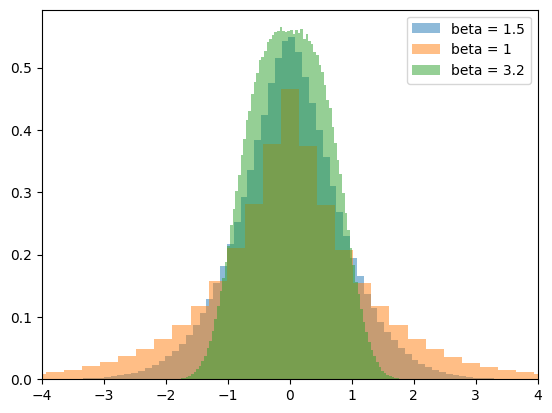

In [9]:
def scale_from_c(c, beta):
    return 1 / (c**(1 / beta))

def exponential_power_sampler(beta, scale, seed=0):
    """ EPD sampler - taken from https://github.com/scipy/scipy/blob/v1.10.1/scipy/stats/_continuous_distns.py#L9398-L9482
    exp(-scale * |x|**beta)
    (note: see equation 9 from https://sci-hub.ru/https://doi.org/10.1080/00949650802290912)
    """
    # see [2]_ for the algorithm
    # see [3]_ for reference implementation in SAS

    a = 1 / beta
    b = np.power(scale, beta)
    rng = np.random.Generator(np.random.SFC64(seed))
    # make it faster
    def f(size=1.):
        """ Sample from the EPD distribution.
        exp(-scale * |x|**beta)
        
        # see equation 9 from https://sci-hub.ru/https://doi.org/10.1080/00949650802290912
        """
        z = rng.gamma(shape=a, scale=b, size=size)
        #z = np.random.gamma(1/beta, size=size)
        y = np.power(z, (1 / beta))
        # convert y to array to ensure masking support
        #y = np.asarray(y)
        mask = rng.random(size=y.shape) < 0.5
        y[mask] *= -1  #y[mask]
        return y
    return f


def beta_exponential_sampler(beta, c):
    """ 
    return sampler from beta exponential distribution (function can be called with no arguments or with size = # argument)
    
    exp(-scale * |x|**beta)
    """
    scale = scale_from_c(c=c, beta=beta)
    return exponential_power_sampler(beta=beta, scale=scale)

# plot histogram from beta exponential distribution
beta = 1.5
c = 1
N = int(1e6)
sampler = beta_exponential_sampler(beta=beta, c=c)
samples = sampler(N)
plt.hist(samples, bins=100, density=True, label=f'beta = {beta}', alpha=0.5)
beta = 1
sampler = beta_exponential_sampler(beta=beta, c=c)
samples = sampler(N)
plt.hist(samples, bins=100, density=True, label=f'beta = {beta}', alpha=0.5)
beta = 3.2
sampler = beta_exponential_sampler(beta=beta, c=c)
samples = sampler(N)
plt.hist(samples, bins=100, density=True, label=f'beta = {beta}', alpha=0.5)
plt.legend()
plt.xlim(-4,4)
plt.show()


0.9999999999999999


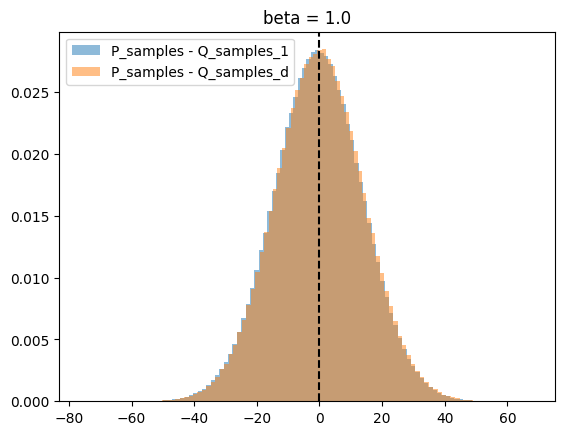

1.0000000000000002


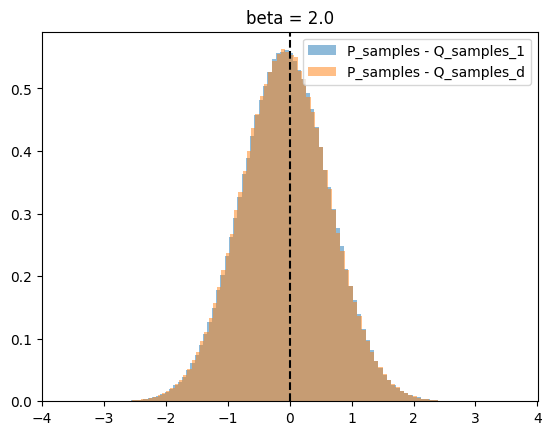

1.0000000000000002


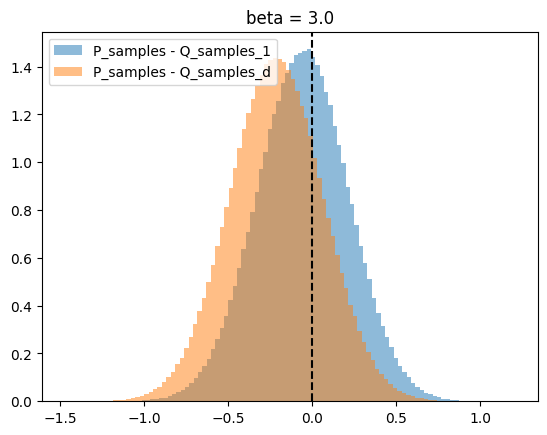

In [59]:
def P(beta, d , N ,sampler):
    samples = sampler(N* d)
    samples = samples.reshape(N, d)
    sample_norms = np.linalg.norm(samples, axis=1, ord=beta) # take norm of samples
    return sample_norms

def Q(beta, d, N, mu, sampler):
    samples = sampler(N* d)
    samples = samples.reshape(N, d)
    # subtract each sample from mu
    samples = samples - mu
    sample_norms = np.linalg.norm(samples, axis=1, ord=beta) # take norm of samples
    return sample_norms

def mu_1(d):
    mu = np.zeros(d) # one hot
    mu[0] = 1
    return mu

def mu_d(d, beta):
    mu = np.ones(d)
    mu = mu / np.linalg.norm(mu, ord=beta)
    return mu 

N = int(1e6)


for beta in [1., 2., 3.]:

    c = 1

    d = 100
    sampler = beta_exponential_sampler(beta=beta, c=c) # this is X


    P_samples = P(beta, d, N, sampler  )
    Q_samples_1 = Q(beta, d, N, mu_1(d), sampler)
    Q_samples_d = Q(beta, d, N, mu_d(d, beta=beta), sampler)

    # plot histogram of P_samples - Q_samples_1
    plt.hist(P_samples - Q_samples_1, bins=100, density=True, label='P_samples - Q_samples_1', alpha=0.5)
    plt.hist(P_samples - Q_samples_d, bins=100, density=True, label='P_samples - Q_samples_d', alpha=0.5)
    plt.legend()
    plt.title(f'beta = {beta}')
    plt.axvline(x=0, color='black', linestyle='--')
    plt.show()




1.0


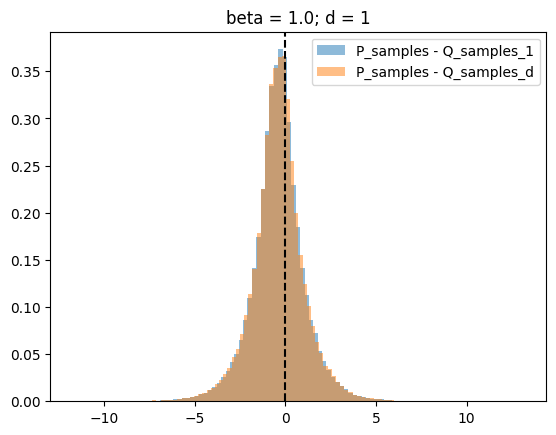

1.0


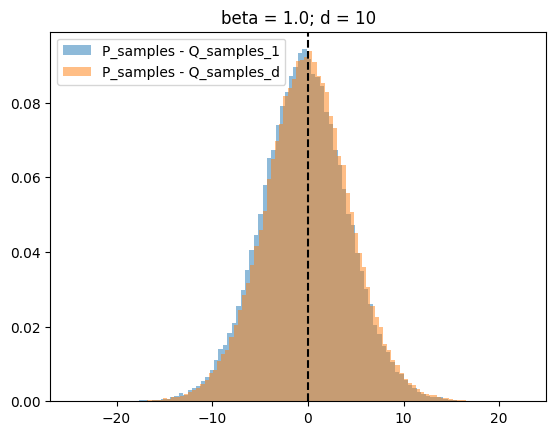

1.0


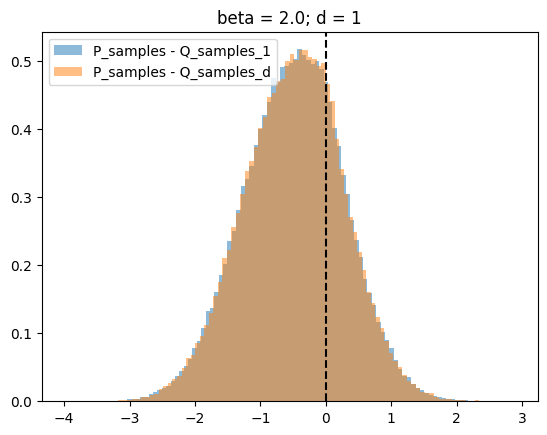

1.0


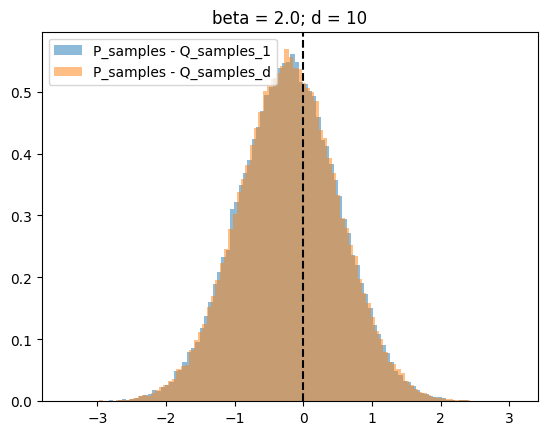

1.0


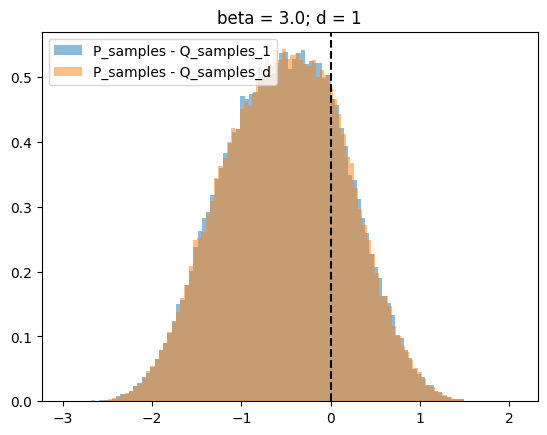

0.9999999999999999


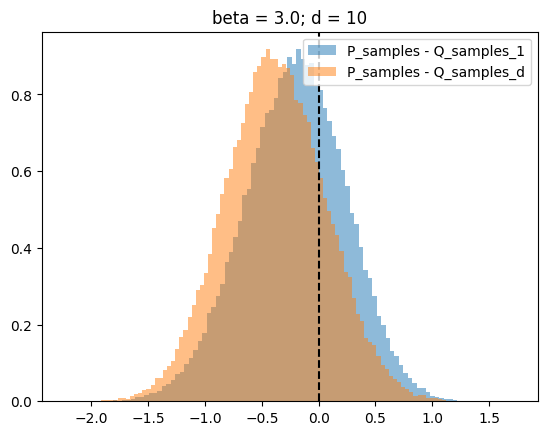

In [64]:
N = int(1e5)


for beta in [1., 2., 3.]:
    for d in[ 1, 10]:
        c = 1
        sampler = beta_exponential_sampler(beta=beta, c=c) # this is X


        P_samples = P(beta, d, N, sampler  )
        Q_samples_1 = Q(beta, d, N, mu_1(d), sampler)
        Q_samples_d = Q(beta, d, N, mu_d(d, beta=beta), sampler)

        # plot histogram of P_samples - Q_samples_1
        plt.hist(P_samples - Q_samples_1, bins=100, density=True, label='P_samples - Q_samples_1', alpha=0.5)
        plt.hist(P_samples - Q_samples_d, bins=100, density=True, label='P_samples - Q_samples_d', alpha=0.5)
        plt.legend()
        plt.title(f'beta = {beta}; d = {d}')
        plt.axvline(x=0, color='black', linestyle='--')
        plt.show()


In [68]:

# 5 seconds * d 
# d = 2 million 
d_ = 2_000_000
(5 * d_)/ 60/60 /24

115.74074074074075

In [65]:
%%timeit
# time sampler
N = int(1e8)

sampler(N)


4.9 s ± 32.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


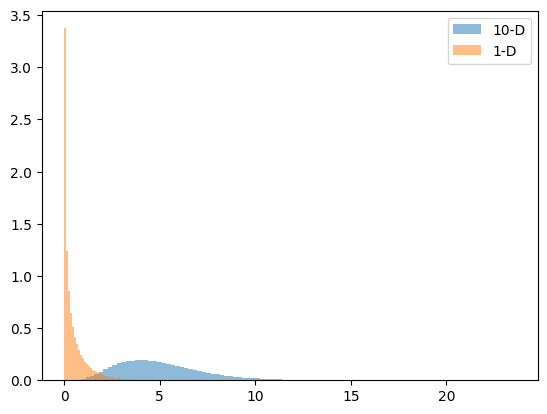

In [ ]:
N = int(1e6)
d = 10
# d dimensional generalized gaussian


beta,c = 2,1

sampler = sampling.beta_exponential_sampler(beta=beta, c=c) # this is X


samples_d = sampler(N*d)
samples_d = samples_d.reshape(N, d)

samples_1 = sampler(N)
samples_1 = samples_1.reshape(N, 1)


# take l-beta norm
sample_d_norms = np.linalg.norm(samples_d, axis=1, ord=beta)
sample_d_norms.shape
#sample_1_norms = np.linalg.norm(samples_1, axis=1, ord=beta) # just the absolute value
sample_1_norms = np.linalg.norm(samples_1, axis=1, ord=beta) **b

plt.hist(sample_d_norms, bins=100, density=True, label=f'{d}-D', alpha=0.5) 
plt.hist(sample_1_norms, bins=100, density=True, label='1-D', alpha=0.5)
plt.legend()
plt.show()



In [19]:
import numpy as np

# First block: mu = [1, 0, ..., 0]
num_samples = 1000000
d = 10
samples_0 = np.random.laplace(size=(num_samples, d))
samples_1 = np.random.laplace(size=(num_samples, d)) 
mu = np.zeros(d)
mu[0] = 1
diffs = np.linalg.norm(samples_0 - mu, ord=1, axis=1) - np.linalg.norm(samples_1, ord=1, axis=1)


print(diffs.shape)
print("diff mean: " + str(np.mean(diffs)))
print("diff std: " + str(np.std(diffs)))

# Output:
# diff mean: 0.36786099348865187
# diff std: 0.810787665591258


(1000000,)
diff mean: 0.37642375828984465
diff std: 4.495643100593354


(1000000,)


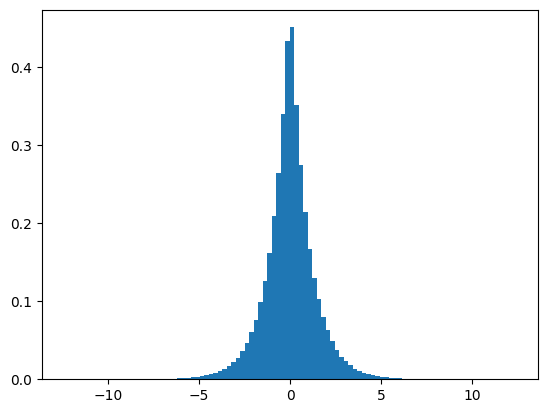

In [29]:
samples__ = np.random.laplace(size=(num_samples, 1))
# flatten
samples__ = samples__.reshape(num_samples, -1)[:,0]
print(samples__.shape)
plt.hist(samples__, bins=100, density=True)
plt.show()

In [30]:
# Second block: mu = [1/d, ..., 1/d]
num_samples = 10000
d = 10
samples_0 = np.random.laplace(size=(num_samples, d))
mu = np.full(d, 1 / d)
samples_1 = np.random.laplace(size=(num_samples, d))

diffs = np.linalg.norm(samples_0 - mu, ord=1, axis=1) - np.linalg.norm(samples_1, ord=1, axis=1)
print("diff mean: " + str(np.mean(diffs)))
print("diff std: " + str(np.std(diffs)))


diff mean: 0.04273138024663139
diff std: 4.4182958876588545


In [37]:

np.linalg.norm(mu, ord=1)


1.0

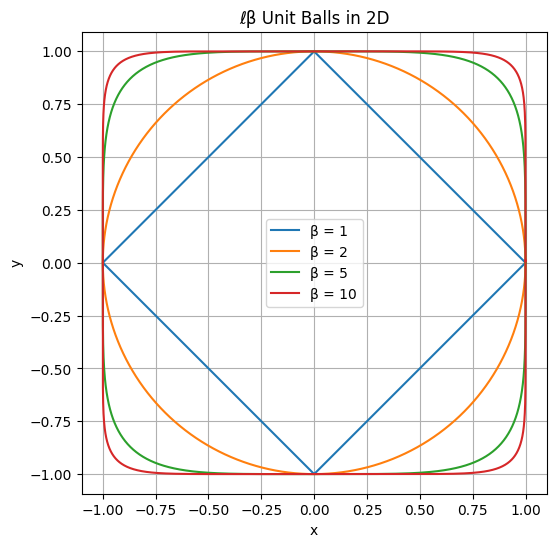

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def l_beta_ball(beta=2.0, num_points=1000):
    # Sample angles for a full circle
    theta = np.linspace(0, 2 * np.pi, num_points)
    
    # Parametric form for L-beta ball boundary
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    # Avoid division by zero issues
    epsilon = 1e-10
    cos_t[np.abs(cos_t) < epsilon] = epsilon
    sin_t[np.abs(sin_t) < epsilon] = epsilon

    x = np.sign(cos_t) * np.abs(cos_t)**(2 / beta)
    y = np.sign(sin_t) * np.abs(sin_t)**(2 / beta)

    return x, y

# Plotting for various beta values
plt.figure(figsize=(6, 6))
for beta in [1, 2, 5, 10]:
    x, y = l_beta_ball(beta)
    plt.plot(x, y, label=f'β = {beta}')

plt.axis('equal')
plt.title('ℓβ Unit Balls in 2D')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()


(500000, 10)


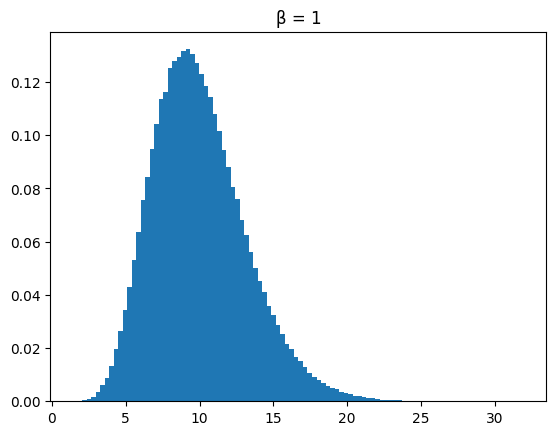

(500000, 10)


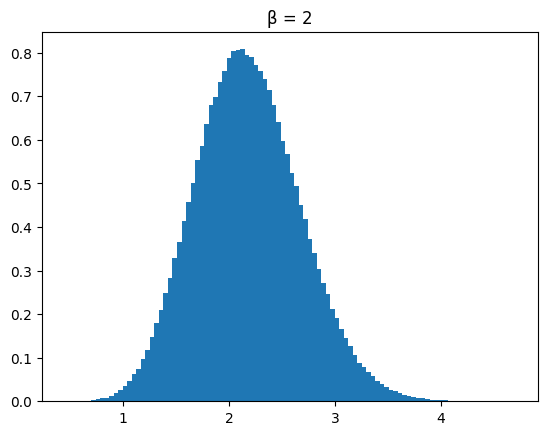

(500000, 10)


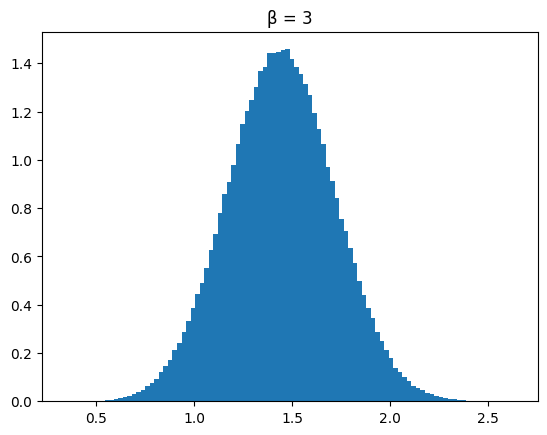

In [55]:
# sample from beta-gaussian, plot histogram of norm
d = 10
N = 500_000
for beta in [1, 2, 3]:
    sampler = sampling.beta_exponential_sampler(beta=beta, c=1)
    samples = sampler(d * N )
    samples = samples.reshape(N, d)
    print(samples.shape)

    plt.hist(np.linalg.norm(samples, ord=beta, axis=1), bins=100, density=True)
    plt.title(f'β = {beta}')
    plt.show()


